# Интерпретация

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных 
data = pd.read_csv("data_unreg.csv")

# Признаки 
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


## Признак 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

feature = "location_marketplace_cnt"

# выбираем 20 объектов
sample_objects = X_test.sample(20, random_state=42)

# базовое значение признака (медиана по train)
x_base = X_train[feature].median()
x_base

np.float64(26222.893860652977)

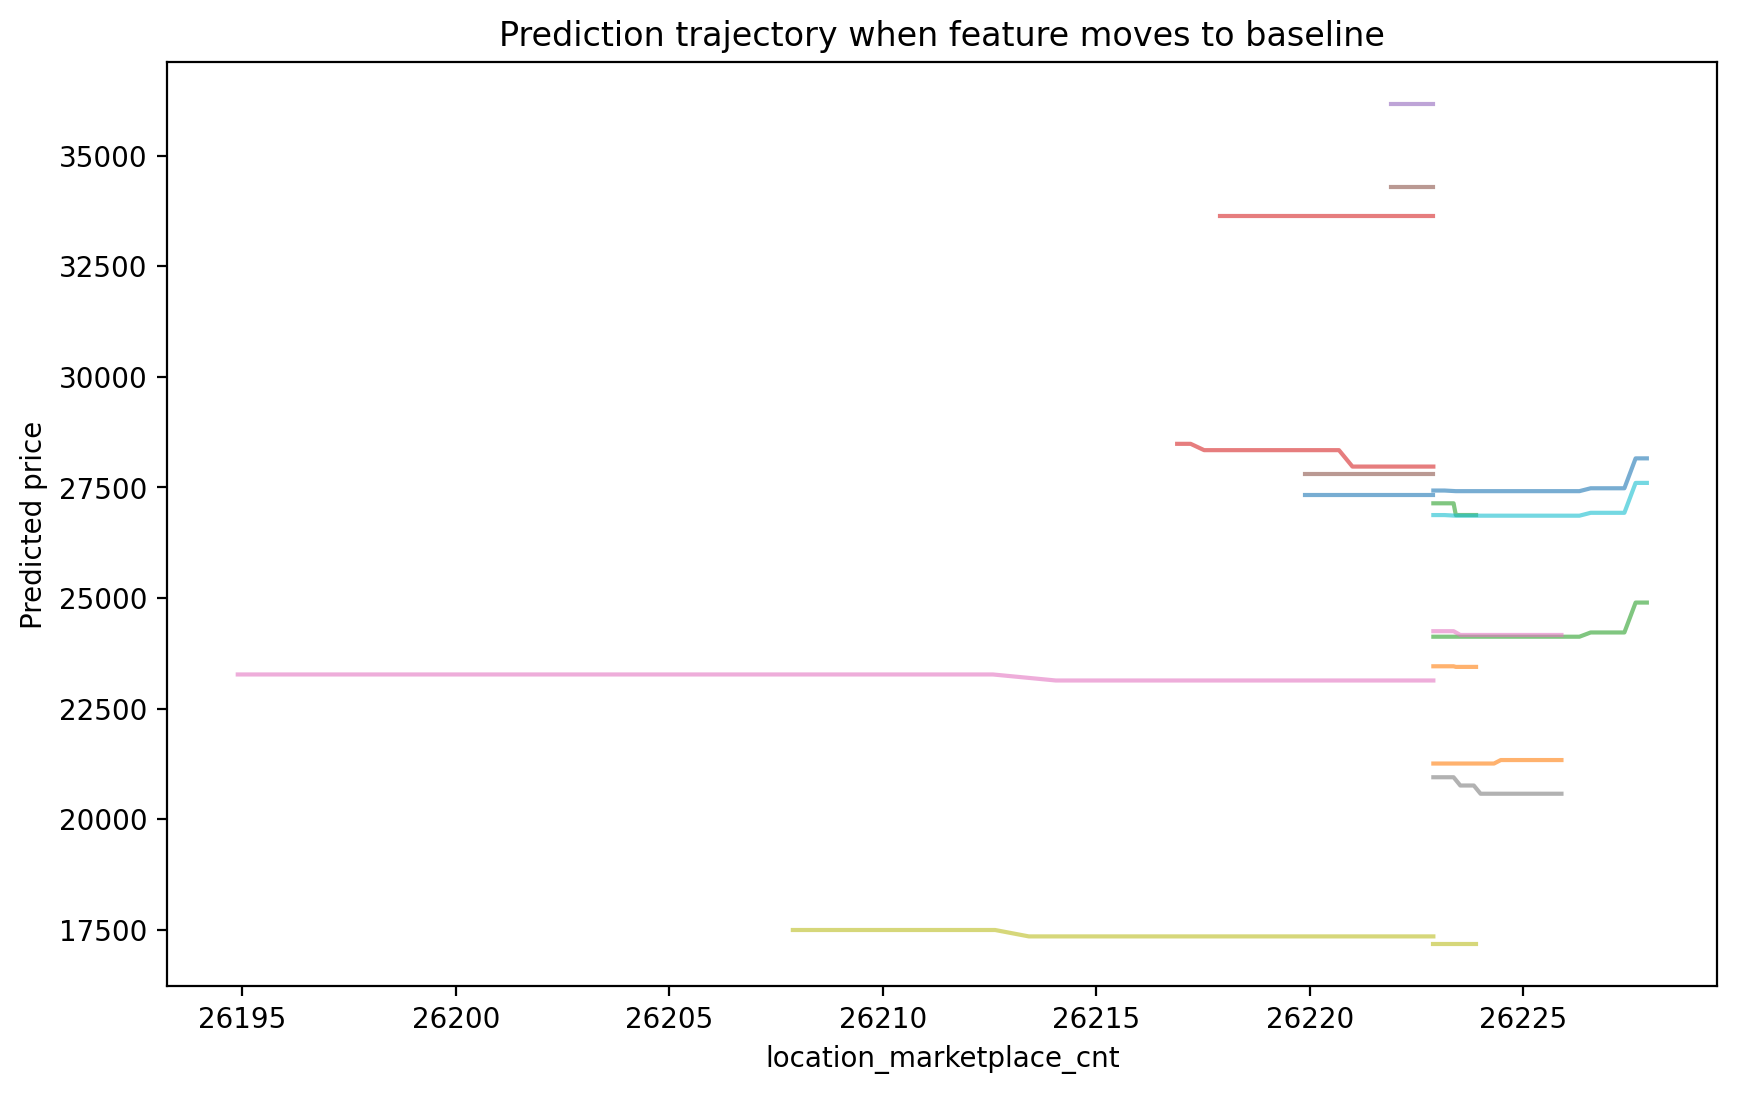

In [3]:
n_steps = 20

plt.figure(figsize=(10,6))

for idx, row in sample_objects.iterrows():

    x_current = row[feature]

    # интерполяция между текущим и базовым значением
    values = np.linspace(x_current, x_base, n_steps)

    preds = []

    for v in values:
        modified = row.copy()
        modified[feature] = v

        pred = gb_model.predict(modified.to_frame().T)[0]
        preds.append(pred)

    plt.plot(values, preds, alpha=0.6)

plt.xlabel(feature)
plt.ylabel("Predicted price")
plt.title("Prediction trajectory when feature moves to baseline")
plt.show()

## Признак 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt

feature = "location_amenity_pharmacy_w_mean_distance"

# выбираем 20 объектов
sample_objects = X_test.sample(20, random_state=42)

# базовое значение признака (медиана по train)
x_base = X_train[feature].median()
x_base

np.float64(324.97053500852525)

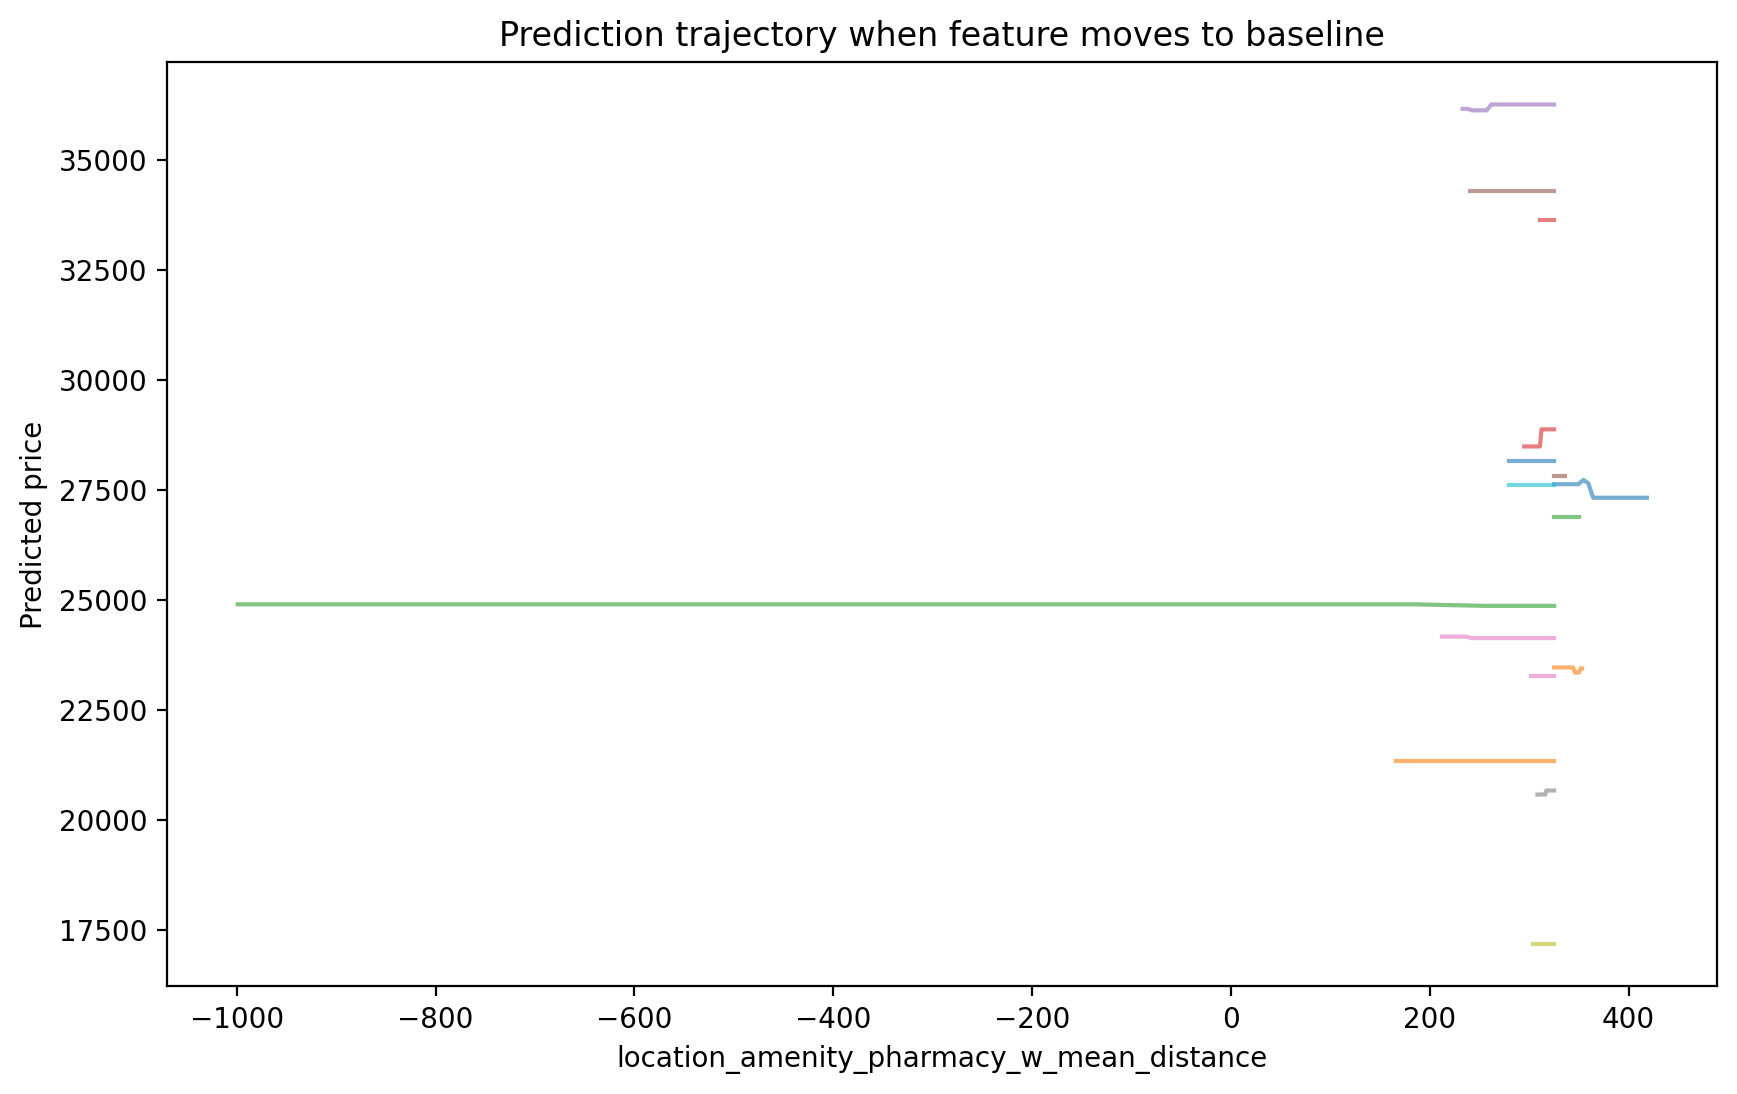

In [5]:
n_steps = 20

plt.figure(figsize=(10,6))

for idx, row in sample_objects.iterrows():

    x_current = row[feature]

    # интерполяция между текущим и базовым значением
    values = np.linspace(x_current, x_base, n_steps)

    preds = []

    for v in values:
        modified = row.copy()
        modified[feature] = v

        pred = gb_model.predict(modified.to_frame().T)[0]
        preds.append(pred)

    plt.plot(values, preds, alpha=0.6)

plt.xlabel(feature)
plt.ylabel("Predicted price")
plt.title("Prediction trajectory when feature moves to baseline")
plt.show()

## Результаты

Полученные графики показывают траектории изменения предсказаний модели для каждого объекта. Каждая линия соответствует одному объекту тестовой выборки. По оси X откладываются значения анализируемого признака, а по оси Y - предсказанное значение целевой переменной.

Анализ графиков позволяет оценить чувствительность модели к изменениям выбранного признака. Если траектории имеют выраженный наклон, это означает, что изменение признака существенно влияет на предсказание модели. Если же линии остаются практически горизонтальными, то влияние признака на результат модели является слабым.

В проведённом эксперименте большинство траекторий изменяются незначительно, что указывает на сравнительно слабую зависимость предсказания модели от рассматриваемых признаков. Это означает, что изменение данных признаков в пределах наблюдаемых диапазонов оказывает ограниченное влияние на прогнозируемую стоимость.

Небольшие ступенчатые изменения предсказаний объясняются использованием модели градиентного бустинга в этом эксперименте. Поскольку модель основана на ансамбле решающих деревьев, зависимость между признаками и предсказанием имеет кусочно-постоянный характер.